# Modelado Evaluación

## 1. Definición del problema de Machine Learning

El objetivo inicial de modelado es construir un **clasificador binario** capaz de diferenciar muestras de controles (`n`) frente a muestras asociadas a diabetes tipo 2 (`t2d`) utilizando **únicamente variables taxonómicas** del microbioma intestinal.
<br>
<br>
Este primer modelo se plantea como **baseline supervisado**. No se incluyen variables de metadata como `dataset_name`, `country`, `age`, `gender` o `bmi`, ya que podrían introducir sesgos o confounding. El objetivo es evaluar si las **abundancias microbianas** contienen señal predictiva por sí mismas.

**Variable objetivo:**
- `0`: control (`n`)
- `1`: diabetes tipo 2 (`t2d`)

**Features**
- columnas taxonómicas que empiezan por `k__` 

## 2. Preparación del dataset binario `n` vs `t2d`

### 2.0. Cargar librerías

In [21]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

### 2.1. Cargar dataset limpio

In [2]:
df_model = pd.read_csv(
    "D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/data/processed/abundance_stoolsubset_clean.csv",
    low_memory=False
)

df_model.shape

(1577, 2135)

### 2.2. Crear subset `n` y `t2d`

In [5]:
df_binary = df_model[df_model["disease"].isin(["n", "t2d"])].copy()

### 2.3. Definir `target`

In [7]:
df_binary["target"] = df_binary["disease"].map({
    "n": 0,
    "t2d": 1
})

df_binary["target"].value_counts()

target
0    710
1    223
Name: count, dtype: int64

### 2.4. Definir `x` y `y`

In [8]:
taxa_cols = [col for col in df_binary.columns if col.startswith("k__")]

X = df_binary[taxa_cols]
y = df_binary["target"]

X.shape, y.shape

((933, 2128), (933,))

## 3. `Train`/`Test`

### 3.1. Separación de datos

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% para test
    random_state=42,    # Reproducubilidad
    stratify=y          # mantener la proporción de las clases n y t2d en train y test
)

### 3.2. Comprobación de proporciones

In [11]:
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(target
 0    0.761394
 1    0.238606
 Name: proportion, dtype: float64,
 target
 0    0.759358
 1    0.240642
 Name: proportion, dtype: float64)

## 4. Baseline: `Logistic Regression`

### 4.1. Definición del pipeline

In [12]:
logistic_pipeline = Pipeline(steps=[
    ("log_transform", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),   # aplicar log1p a las abundancias para reducir asimetrías
    ("feature_selection", SelectKBest(score_func=f_classif, k=300)),    # selecciona las 300 variables más relacionadas con el target dentro del train
    ("scaler", StandardScaler()),       # estandariza variables
    ("model", LogisticRegression(       
        max_iter=5000,
        class_weight="balanced",        # compesa el desbalance entre n y t2d
        random_state=42
    ))
])

### 4.2. Entrenamiento del modelo

In [14]:
logistic_pipeline.fit(X_train, y_train)
# Ajusta todo el pipeline usando solo los datos de entrenamiento
# Aprende: la transformación, las features seleccionadas, el escalado, y los coeficientes del modelo

c:\Users\gonza\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 648  649  650  651  669  670  730  731  732  743  744  747  748  750
  751  752  818  819  820  821  822  823  824  833  834  835  875  876
  879  880  945  946  955  956  963  964  965  978 1012 1027 1029 1032
 1038 1039 1040 1063 1064 1085 1086 1094 1095 1103 1104 1119 1128 1129
 1130 1131 1132 1133 1153 1154 1182 1183 1186 1187 1207 1208 1212 1213
 1224 1225 1236 1237 1238 1239 1240 1241 1242 1243 1268 1269 1270 1271
 1272 1273 1286 1287 1288 1289 1290 1291 1304 1305 1329 1338 1339 1340
 1341 1342 1343 1344 1353 1354 1374 1375 1376 1377 1382 1383 1386 1387
 1388 1390 1391 1397 1398 1399 1402 1403 1404 1407 1428 1434 1437 1438
 1439 1440 1441 1442 1443 1446 1447 1448 1475 1476 1477 1478 1499 1500
 1501 1502 1503 1504 1508 1509 1514 1515 1527 1528 1529 1530 1531 1538
 1539 1541 1607 1608 1609 1614 1615 1616 1617 1618 1619 1626 1627 16

,steps,"[('log_transform', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<ufunc 'log1p'>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,'one-to-one'
,kw_args,None


### 4.3. Predicción sobre `test`

In [ ]:
# predecir clase final `0` o `1`
y_pred = logistic_pipeline.predict(X_test)

# devuelve la probabilidad estimada de pertenecer a la clase `1`, es decir `t2d`
y_proba = logistic_pipeline.predict_proba(X_test)[:, 1]

### 4.4. Métricas principales

In [16]:
metrics_logistic = {
    "accuracy": accuracy_score(y_test, y_pred),     # aciertos globales
    "precision": precision_score(y_test, y_pred),   # de los predichos como `t2d`
    "recall": recall_score(y_test, y_pred),         # de los `t2d` reales, cuántos detectó
    "f1_score": f1_score(y_test, y_pred),           # equilibrio entre precision y recall
    "roc_auc": roc_auc_score(y_test, y_proba)       # capacidad de separar clases usando probabilidades
}

metrics_logistic

{'accuracy': 0.7593582887700535,
 'precision': 0.5,
 'recall': 0.6222222222222222,
 'f1_score': 0.5544554455445545,
 'roc_auc': 0.7450704225352112}

### 4.5. Reporte de la clasificación

In [17]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["n", "t2d"]
))

              precision    recall  f1-score   support

           n       0.87      0.80      0.84       142
         t2d       0.50      0.62      0.55        45

    accuracy                           0.76       187
   macro avg       0.69      0.71      0.69       187
weighted avg       0.78      0.76      0.77       187



### 4.6. Matriz de confusión

In [18]:
confusion_matrix(y_test, y_pred)

array([[114,  28],
       [ 17,  28]])

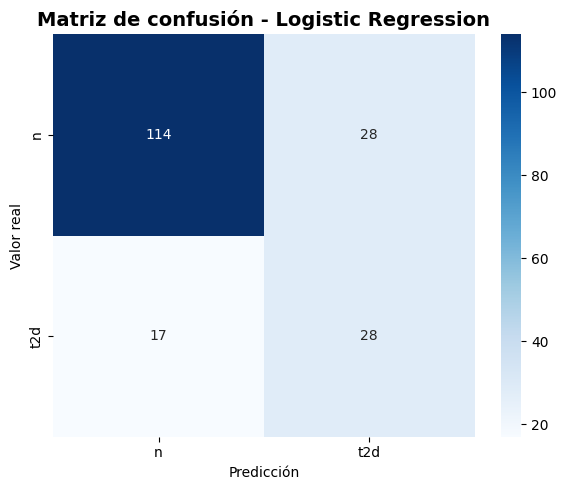

In [23]:
# Gráfico
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["n", "t2d"],
    yticklabels=["n", "t2d"]
)

plt.title("Matriz de confusión - Logistic Regression", fontsize=14, fontweight="bold")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/matriz_confusion_LogReg_01.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

El modelo baseline de **Logistic Regression** alcanza un *accuracy* de **0.76** y un *ROC-AUC* de **0.75**. Para la clase `t2d`, obtiene un *recall* de **0.62**, lo que indica que detecta aproximadamente el 62% de los casos de diabetes tipo 2. 
<br>
Sin embargo, la *precision* para `t2d` es **0.50**, por lo que el modelo genera un <u>número relevante de **falsos positivos**</u>. Estos resultados sugieren que existe cierta señal predictiva en el perfil taxonómico, aunque será necesario <u>comparar con modelos no lineales</u> y ajustar el preprocesamiento para mejorar el rendimiento.

### 4.7. Conclusión del baseline

La regresión logística funciona como primer baseline interpretable. Los resultados muestran una **capacidad moderada** para diferenciar controles de muestras asociadas a diabetes tipo 2, con *ROC-AUC* de **0.75**. El modelo detecta parte de los casos `t2d`, aunque todavía presenta falsos positivos y falsos negativos. Esto justifica continuar con **modelos no lineales** como **Random Forest**, **Gradient Boosting** y **SVM**, así como probar estrategias de selección de variables y reducción dimensional.

## 5. Entrenamiento de modelos supervisados

### 5.1. Importar modelos adicionales

In [24]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

### 5.2. Definir pipelines

In [25]:
k_features = 300

models = {
    "Logistic Regression": Pipeline(steps=[
        ("log_transform", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("feature_selection", SelectKBest(score_func=f_classif, k=k_features)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline(steps=[
        ("log_transform", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("feature_selection", SelectKBest(score_func=f_classif, k=k_features)),
        ("model", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline(steps=[
        ("log_transform", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("feature_selection", SelectKBest(score_func=f_classif, k=k_features)),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ]),

    "SVM": Pipeline(steps=[
        ("log_transform", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("feature_selection", SelectKBest(score_func=f_classif, k=k_features)),
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=True,
            random_state=42
        ))
    ]),

    "KNN": Pipeline(steps=[
        ("log_transform", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("feature_selection", SelectKBest(score_func=f_classif, k=k_features)),
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=5
        ))
    ])
}

## 6. Evaluación comparativa

## 8. Interpretación

## 9. Selección del modelo final